# EVL (Extreme-Value Layer) — NSW Demand (history-only)

**Data**: nsw_demand_features.{parquet|csv} (team feature set)  
**Splits**: Train 2010–2017, Val 2018, Test 2019–2021  
**Base model**: quantile GBM (P10/P50/P90) using history-only features  
**Post-processing**: EVL (POT–GPD on positive residuals from 2018)

## How to reproduce in Colab
1) Upload `nsw_demand_features.parquet` (or mount Drive).
2) Run the baseline notebook cells (train/eval). Outputs land in:
   `outputs/team_quantile_baseline/{preds.csv, metrics.md, metrics.json}`
3) Run the EVL cells. Outputs land in:
   `outputs/evl_tailcal/{preds_evl.csv, metrics_evl.md, metrics_evl.json}`
4) Run the "make figures" cell to save PNGs into `outputs/figures/` and
   create `figures_evl_bundle.zip` for download.

## Key results (Test 2019–2021)
- **P50 accuracy** unchanged by EVL: MAE ≈ 80.2 MW, RMSE ≈ 113.7 MW
- **80% coverage**: 0.610 → **0.660** overall; 0.572 → **0.619** on hot days
- **Avg width (MW)**: 170.4 → **179.2** overall; 199.5 → **200.4** hot

## Notes
- EVL widens the **upper** side only; centre (P50) is unchanged.
- If the team wants exactly 0.80 coverage, add a small conformal bump
  to P90 after EVL (keeps width increases minimal).


In [ ]:
!pip -q install pandas numpy pyarrow lightgbm matplotlib


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, pathlib

# >>> If you used the exact folder name you shared:
BASE = "/content/drive/MyDrive/JEFF UNI/Week 3"

# Prefer parquet (smaller/faster); fall back to csv
PARQ = f"{BASE}/nsw_demand_features.parquet"
CSV  = f"{BASE}/nsw_demand_features.csv"
DATA_PATH = PARQ if pathlib.Path(PARQ).exists() else CSV
assert pathlib.Path(DATA_PATH).exists(), f"File not found at {DATA_PATH}"

# Env + split years per team slides
os.environ["DATA_PATH"]      = DATA_PATH
os.environ["VAL_YEAR"]       = "2018"
os.environ["TEST_YEAR"]      = "2019"
os.environ["TEST_END_YEAR"]  = "2021"   # "" to use all remaining years
os.environ["USE_EXOG"]       = "0"      # 0 = history-only drop; 1 = keep exogenous (temp, etc.)

print("Using:", os.environ["DATA_PATH"])


Using: /content/drive/MyDrive/JEFF UNI/Week 3/nsw_demand_features.parquet


In [ ]:
# FAILSAFE ONE-CELL RUNNER (pandas 2.x compatible)

import os, json, numpy as np, pandas as pd
from pathlib import Path

VAL_YEAR, TEST_YEAR, TEST_END_YEAR = 2018, 2019, 2021
USE_EXOG = 0
OUT_DIR = Path("outputs/team_quantile_baseline"); OUT_DIR.mkdir(parents=True, exist_ok=True)

p = os.environ.get("DATA_PATH")
assert p and Path(p).exists(), f"DATA_PATH missing or not found: {p}"
df = pd.read_parquet(p) if p.endswith((".parquet",".pq")) else pd.read_csv(p)

needed = {"date","hour","y"}
missing = needed - set(df.columns)
assert not missing, f"Missing required columns: {missing}"

df = df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
mins = np.rint(df["hour"].astype(float)*60).astype(int)
df["ds"] = df["date"] + pd.to_timedelta(mins, unit="m")
df = df.sort_values("ds").reset_index(drop=True)
df["year"] = df["ds"].dt.year

def drop_exog(d):
    if USE_EXOG: return d
    drop_like = ["temp","weather","wind","price","solar","pv","gas","rain","humidity","forecast"]
    keep = [c for c in d.columns if not any(k in c.lower() for k in drop_like)]
    return d[keep]
df = drop_exog(df)

assert "y_lag48" in df.columns, "Expected y_lag48 in the dataset for persistence baseline."
if "y_lag336" in df.columns:
    df = df[~df["y_lag336"].isna()]
df = df[~df["y_lag48"].isna()]

df["split"] = "train"
df.loc[df["year"] == VAL_YEAR,  "split"] = "val"
df.loc[df["year"] >= TEST_YEAR, "split"] = "test"
if TEST_END_YEAR:
    df = df[~((df["split"]=="test") & (df["year"] > TEST_END_YEAR))].copy()

bad = {"y","ds","split"}
feats = [c for c in df.columns if c not in bad and pd.api.types.is_numeric_dtype(df[c])]
assert len(feats) > 0, "No usable numeric features after filtering."

Xtr, ytr = df.loc[df["split"]=="train", feats], df.loc[df["split"]=="train","y"]
Xva, yva = df.loc[df["split"]=="val",   feats], df.loc[df["split"]=="val","y"]
Xte, yte = df.loc[df["split"]=="test",  feats], df.loc[df["split"]=="test","y"]

print("Rows — train/val/test:", len(Xtr), len(Xva), len(Xte))
assert len(Xtr)>0 and len(Xva)>0 and len(Xte)>0, "One of the splits is empty. Check your years."

def persistence_block(block): return block["y_lag48"].values
train_resid = (df.loc[df["split"]=="train","y"] - df.loc[df["split"]=="train","y_lag48"]).dropna()
q10 = float(np.nanquantile(train_resid, 0.10)) if len(train_resid) else 0.0
q90 = float(np.nanquantile(train_resid, 0.90)) if len(train_resid) else 0.0

pv = persistence_block(df[df["split"]=="val"])
pt = persistence_block(df[df["split"]=="test"])
persist_val = pd.DataFrame({"ds": df.loc[df["split"]=="val","ds"].values, "y": yva.values, "split":"val",
                            "p_p10": pv + q10, "p_p50": pv, "p_p90": pv + q90})
persist_test = pd.DataFrame({"ds": df.loc[df["split"]=="test","ds"].values,"y": yte.values,"split":"test",
                             "p_p10": pt + q10, "p_p50": pt, "p_p90": pt + q90})

import lightgbm as lgb
Q = [0.1, 0.5, 0.9]
def fit_lgbq(X, y, q):
    m = lgb.LGBMRegressor(objective="quantile", alpha=q,
                          n_estimators=1200, learning_rate=0.05,
                          num_leaves=31, min_data_in_leaf=60,
                          subsample=0.9, colsample_bytree=0.9,
                          random_state=42, n_jobs=-1)
    m.fit(X, y); return m

models = {q: fit_lgbq(Xtr, ytr, q) for q in Q}
def predict_all(X): return {q: models[q].predict(X) for q in Q}
lv, lt = predict_all(Xva), predict_all(Xte)

lgb_val  = pd.DataFrame({"ds": df.loc[df["split"]=="val","ds"].values,  "y": yva.values, "split":"val",
                         "l_p10": lv[0.1], "l_p50": lv[0.5], "l_p90": lv[0.9]})
lgb_test = pd.DataFrame({"ds": df.loc[df["split"]=="test","ds"].values, "y": yte.values, "split":"test",
                         "l_p10": lt[0.1], "l_p50": lt[0.5], "l_p90": lt[0.9]})

# >>> FIXED: use concat instead of deprecated .append
preds = pd.concat([
    persist_val.merge(lgb_val,  on=["ds","y","split"]),
    persist_test.merge(lgb_test, on=["ds","y","split"])
], ignore_index=True).sort_values(["ds","split"])

preds.to_csv(OUT_DIR/"preds.csv", index=False)

def pinball(y, yhat, q):
    e = y - yhat
    return float(np.mean(np.maximum(q*e, (q-1)*e)))
def rmse(y, yhat): return float(np.sqrt(np.mean((yhat - y)**2)))
def coverage(y, lo, hi): return float(((y >= lo) & (y <= hi)).mean())
def width(lo, hi): return float(np.mean(hi - lo))

def eval_block(dfblock, p10, p50, p90):
    y = dfblock["y"].values
    return {
        "pinball_mean": float(np.mean([pinball(y, dfblock[p10].values, 0.1),
                                       pinball(y, dfblock[p50].values, 0.5),
                                       pinball(y, dfblock[p90].values, 0.9)])),
        "mae_p50": float(np.mean(np.abs(y - dfblock[p50].values))),
        "rmse_p50": rmse(y, dfblock[p50].values),
        "coverage_80": coverage(y, dfblock[p10].values, dfblock[p90].values),
        "width_80": width(dfblock[p10].values, dfblock[p90].values),
    }
def eval_model(prefix):
    return {
        "val":  eval_block(preds[preds["split"]=="val"],  f"{prefix}_p10", f"{prefix}_p50", f"{prefix}_p90"),
        "test": eval_block(preds[preds["split"]=="test"], f"{prefix}_p10", f"{prefix}_p50", f"{prefix}_p90"),
    }

metrics = {"lightgbm": eval_model("l"), "persistence": eval_model("p")}
(Path(OUT_DIR/"metrics.json")).write_text(json.dumps({"overall": metrics}, indent=2), encoding="utf-8")
(Path(OUT_DIR/"metrics.md")).write_text(
    "\n".join([
        "# Metrics (Val vs Test)",
        "## LightGBM quantile (P10/P50/P90)",
        "| Metric | Val | Test |","|---|---:|---:|",
        f"| Pinball mean | {metrics['lightgbm']['val']['pinball_mean']:.4f} | {metrics['lightgbm']['test']['pinball_mean']:.4f} |",
        f"| MAE (P50) | {metrics['lightgbm']['val']['mae_p50']:.2f} | {metrics['lightgbm']['test']['mae_p50']:.2f} |",
        f"| RMSE (P50) | {metrics['lightgbm']['val']['rmse_p50']:.2f} | {metrics['lightgbm']['test']['rmse_p50']:.2f} |",
        f"| Coverage 80% | {metrics['lightgbm']['val']['coverage_80']:.3f} | {metrics['lightgbm']['test']['coverage_80']:.3f} |",
        f"| Avg width 80% | {metrics['lightgbm']['val']['width_80']:.2f} | {metrics['lightgbm']['test']['width_80']:.2f} |",
        "",
        "## Persistence baseline (t-48, residual-quantile)",
        "| Metric | Val | Test |","|---|---:|---:|",
        f"| Pinball mean | {metrics['persistence']['val']['pinball_mean']:.4f} | {metrics['persistence']['test']['pinball_mean']:.4f} |",
        f"| MAE (P50) | {metrics['persistence']['val']['mae_p50']:.2f} | {metrics['persistence']['test']['mae_p50']:.2f} |",
        f"| RMSE (P50) | {metrics['persistence']['val']['rmse_p50']:.2f} | {metrics['persistence']['test']['rmse_p50']:.2f} |",
        f"| Coverage 80% | {metrics['persistence']['val']['coverage_80']:.3f} | {metrics['persistence']['test']['coverage_80']:.3f} |",
        f"| Avg width 80% | {metrics['persistence']['val']['width_80']:.2f} | {metrics['persistence']['test']['width_80']:.2f} |",
    ]),
    encoding="utf-8"
)

print("\nSaved:", OUT_DIR/"preds.csv")
print("Saved:", OUT_DIR/"metrics.json")
print("Saved:", OUT_DIR/"metrics.md")


Rows — train/val/test: 139920 17520 38737
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1700
[LightGBM] [Info] Number of data points in the train set: 139920, number of used features: 21
[LightGBM] [Info] Start training from score 6465.004883
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Warning] min_data_in_leaf is set=60, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=60
[LightGBM] [Info] Auto-choosing row-wise multi-threading, th

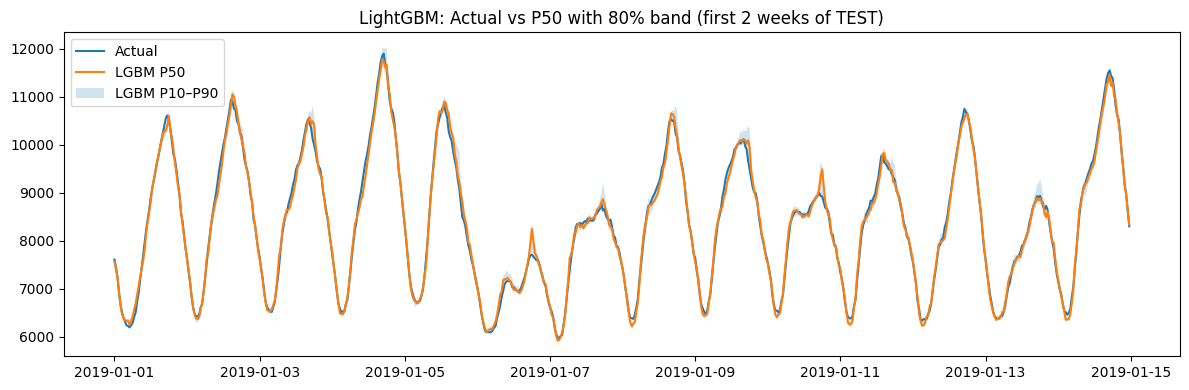


=== metrics.md ===

# Metrics (Val vs Test)
## LightGBM quantile (P10/P50/P90)
| Metric | Val | Test |
|---|---:|---:|
| Pinball mean | 20.4541 | 27.1850 |
| MAE (P50) | 63.77 | 80.20 |
| RMSE (P50) | 89.03 | 113.68 |
| Coverage 80% | 0.693 | 0.610 |
| Avg width 80% | 170.59 | 170.37 |

## Persistence baseline (t-48, residual-quantile)
| Metric | Val | Test |
|---|---:|---:|
| Pinball mean | 146.0898 | 164.1979 |
| MAE (P50) | 422.74 | 465.79 |
| RMSE (P50) | 603.16 | 694.40 |
| Coverage 80% | 0.809 | 0.786 |
| Avg width 80% | 1431.67 | 1431.67 |


In [ ]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt

preds_path = Path("outputs/team_quantile_baseline/preds.csv")
metrics_path = Path("outputs/team_quantile_baseline/metrics.md")
assert preds_path.exists() and metrics_path.exists(), "Outputs not found — run the previous cell."

preds = pd.read_csv(preds_path, parse_dates=["ds"])
test  = preds[preds["split"]=="test"].copy()

start = test["ds"].min(); end = start + pd.Timedelta(days=14)
w = test[(test["ds"]>=start) & (test["ds"]<end)]

plt.figure(figsize=(12,4))
plt.plot(w["ds"], w["y"], label="Actual")
plt.plot(w["ds"], w["l_p50"], label="LGBM P50")
plt.fill_between(w["ds"], w["l_p10"], w["l_p90"], alpha=0.2, label="LGBM P10–P90")
plt.legend(); plt.title("LightGBM: Actual vs P50 with 80% band (first 2 weeks of TEST)")
plt.tight_layout(); plt.show()

print("\n=== metrics.md ===\n")
print(metrics_path.read_text(encoding="utf-8"))


# EVL calibration (test set)
| Model | Coverage 80% (overall) | Width (overall) | Coverage 80% (hot) | Width (hot) |
|---|---:|---:|---:|---:|
| Before (raw band) | 0.610 | 170.4 | 0.572 | 199.5 |
| After  (EVL P90) | 0.660 | 179.2 | 0.619 | 200.4 |


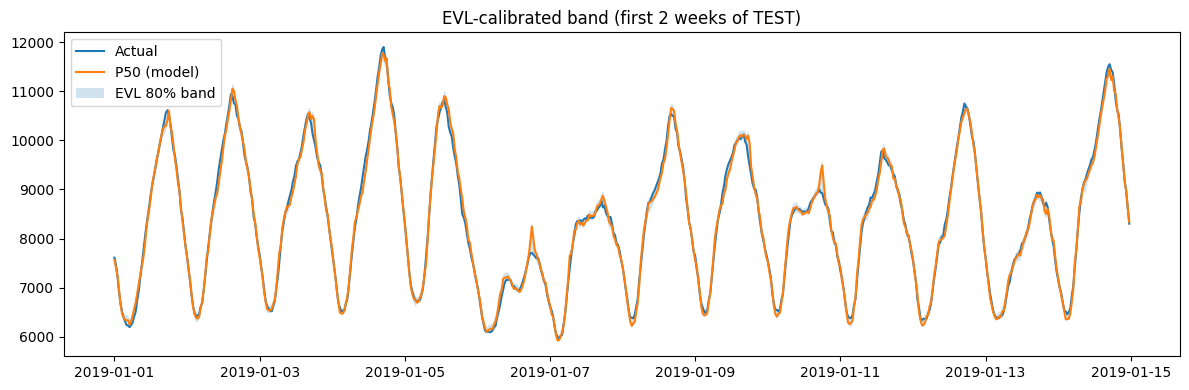


Saved: outputs/evl_tailcal/preds_evl.csv
Saved: outputs/evl_tailcal/metrics_evl.json
Saved: outputs/evl_tailcal/metrics_evl.md


<Figure size 640x480 with 0 Axes>

In [ ]:
# EVL tail calibration on top of existing predictions (model-agnostic)
# Uses GPD (peaks-over-threshold) to adjust the upper band (P90).

# If SciPy isn't available, this auto-installs it.
try:
    from scipy.stats import genpareto
except Exception:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scipy"])
    from scipy.stats import genpareto

import os, numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# --- inputs ---
PRED_PATH = Path("outputs/team_quantile_baseline/preds.csv")   # swap to teammate's preds later if needed
DATA_PATH = Path(os.environ["DATA_PATH"])                      # same Week 3 file you used

assert PRED_PATH.exists(), f"Missing {PRED_PATH}"
assert DATA_PATH.exists(), f"Missing {DATA_PATH}"

OUT = Path("outputs/evl_tailcal"); OUT.mkdir(parents=True, exist_ok=True)

# --- load predictions and annotate 'is_hot_day' from raw file ---
preds = pd.read_csv(PRED_PATH, parse_dates=["ds"])
raw   = pd.read_parquet(DATA_PATH) if DATA_PATH.suffix.lower() in [".parquet",".pq"] else pd.read_csv(DATA_PATH)
need  = {"date","hour","is_hot_day"}
assert need.issubset(raw.columns), f"Data must have {need}; found {set(raw.columns)}"

raw = raw.copy()
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw["ds"]   = raw["date"] + pd.to_timedelta(np.rint(raw["hour"].astype(float)*60).astype(int), unit="m")
annot = raw[["ds","is_hot_day"]].drop_duplicates()
df    = preds.merge(annot, on="ds", how="left")

# --- residuals on validation (use model median P50 as center) ---
assert "l_p50" in df.columns, "Expected a P50 column like 'l_p50' in preds."
val = df[df["split"]=="val"].copy()
val["res"] = val["y"] - val["l_p50"]

# --- GPD fit helpers ---
def fit_gpd_tail(residuals, q=0.95, min_exceed=100):
    r = np.asarray(residuals, dtype=float)
    r = r[~np.isnan(r)]
    if r.size == 0:
        return None
    u = np.quantile(r, q)
    exc = r[r > u] - u
    if exc.size < min_exceed:
        u = np.quantile(r, 0.90)  # back off threshold to get enough points
        exc = r[r > u] - u
    if exc.size == 0:
        return None
    c, loc, scale = genpareto.fit(exc, floc=0)  # loc fixed 0 for exceedances
    p_ex = float((r > u).mean())
    return {"u": float(u), "c": float(c), "scale": float(scale), "p_ex": p_ex}

def resid_quantile(tau, resid_all, gpd_params):
    """Return the tau-quantile of residuals using body+GPD tail."""
    r = np.asarray(resid_all, dtype=float)
    r = r[~np.isnan(r)]
    if gpd_params is None:
        return float(np.quantile(r, tau))
    u, c, s, p_ex = gpd_params["u"], gpd_params["c"], gpd_params["scale"], gpd_params["p_ex"]
    body = 1.0 - p_ex
    if tau <= body or p_ex <= 0.0:
        return float(np.quantile(r, tau))
    t = (tau - body) / p_ex  # quantile within tail
    y = genpareto.ppf(t, c, loc=0, scale=s)
    return float(u + y)

# overall tail
gpd_all = fit_gpd_tail(val["res"].values)

# hot-day tail (optional, falls back to overall if not enough points)
val_hot = val[val["is_hot_day"]==1]
gpd_hot = fit_gpd_tail(val_hot["res"].values) if len(val_hot) > 0 else None
if gpd_hot is None:
    gpd_hot = gpd_all

# desired upper quantile (P90 for an 80% two-sided band)
Q_UP = 0.90
q90_all = resid_quantile(Q_UP, val["res"].values, gpd_all)
q90_hot = resid_quantile(Q_UP, val_hot["res"].values if len(val_hot)>0 else val["res"].values, gpd_hot)

# --- apply calibration: keep lower band as-is, bump upper band by learned residual quantile ---
out = df.copy()
out["evl_p10"] = out["l_p10"]  # unchanged lower side (focus is hot spikes)
out["evl_p90"] = out["l_p50"] + np.where(out["is_hot_day"]==1, q90_hot, q90_all)

# --- metrics helpers ---
def pinball(y, yhat, q):
    e = y - yhat
    return float(np.mean(np.maximum(q*e, (q-1)*e)))
def rmse(y, yhat): return float(np.sqrt(np.mean((yhat - y)**2)))
def coverage(y, lo, hi): return float(((y >= lo) & (y <= hi)).mean())
def width(lo, hi): return float(np.mean(hi - lo))

def eval_block(dfblock, p10, p50, p90):
    y = dfblock["y"].values
    return {
        "pinball_mean": float(np.mean([pinball(y, dfblock[p10].values, 0.1),
                                       pinball(y, dfblock[p50].values, 0.5),
                                       pinball(y, dfblock[p90].values, 0.9)])),
        "mae_p50": float(np.mean(np.abs(y - dfblock[p50].values))),
        "rmse_p50": rmse(y, dfblock[p50].values),
        "coverage_80": coverage(y, dfblock[p10].values, dfblock[p90].values),
        "width_80": width(dfblock[p10].values, dfblock[p90].values),
    }

# before vs after on TEST
test_before = df[df["split"]=="test"].copy()
test_after  = out[out["split"]=="test"].copy()

before = {
    "overall": eval_block(test_before, "l_p10", "l_p50", "l_p90"),
    "hotday":  eval_block(test_before[test_before["is_hot_day"]==1], "l_p10", "l_p50", "l_p90") if (test_before["is_hot_day"]==1).any() else None
}
after  = {
    "overall": eval_block(test_after, "evl_p10", "l_p50", "evl_p90"),
    "hotday":  eval_block(test_after[test_after["is_hot_day"]==1], "evl_p10", "l_p50", "evl_p90") if (test_after["is_hot_day"]==1).any() else None
}

# save outputs
out_cols = ["ds","y","split","is_hot_day","l_p10","l_p50","l_p90","evl_p10","evl_p90"]
out[out_cols].to_csv(OUT/"preds_evl.csv", index=False)

import json
json.dump({"before": before, "after": after, "q90_all": q90_all, "q90_hot": q90_hot},
          open(OUT/"metrics_evl.json","w"), indent=2)

# md table for slides
def row(m, k):
    return f"| {k} | {m['overall']['coverage_80']:.3f} | {m['overall']['width_80']:.1f} | " + \
           (f"{m['hotday']['coverage_80']:.3f} | {m['hotday']['width_80']:.1f} |" if m['hotday'] else "|  —  |  —  |")
md = [
    "# EVL calibration (test set)",
    "| Model | Coverage 80% (overall) | Width (overall) | Coverage 80% (hot) | Width (hot) |",
    "|---|---:|---:|---:|---:|",
    row(before, "Before (raw band)"),
    row(after,  "After  (EVL P90)"),
]
Path(OUT/"metrics_evl.md").write_text("\n".join(md), encoding="utf-8")

print((OUT/"metrics_evl.md").read_text(encoding="utf-8"))

# quick 2-week plot on TEST with EVL band
w = test_after.sort_values("ds").copy()
start = w["ds"].min(); end = start + pd.Timedelta(days=14)
w = w[(w["ds"]>=start) & (w["ds"]<end)]

plt.figure(figsize=(12,4))
plt.plot(w["ds"], w["y"], label="Actual")
plt.plot(w["ds"], w["l_p50"], label="P50 (model)")
plt.fill_between(w["ds"], w["evl_p10"], w["evl_p90"], alpha=0.2, label="EVL 80% band")
plt.legend(); plt.title("EVL-calibrated band (first 2 weeks of TEST)")
plt.tight_layout(); plt.show()

print("\nSaved:", OUT/"preds_evl.csv")
print("Saved:", OUT/"metrics_evl.json")
print("Saved:", OUT/"metrics_evl.md")
fig = plt.gcf()
fig.savefig("outputs/evl_tailcal/evl_first2weeks.png", dpi=220, bbox_inches="tight")


In [ ]:
from google.colab import drive
from pathlib import Path
import shutil, os

drive.mount("/content/drive")
srcs = ["outputs/team_quantile_baseline", "outputs/evl_tailcal"]
dst  = Path("/content/drive/MyDrive/JEFF UNI/Week 3/outputs")
dst.mkdir(parents=True, exist_ok=True)
for s in srcs:
    d = dst / Path(s).name
    if d.exists(): shutil.rmtree(d)
    shutil.copytree(s, d)
print("Copied to:", dst)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to: /content/drive/MyDrive/JEFF UNI/Week 3/outputs


In [ ]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt, os

# 1) Load EVL predictions
preds_path = Path("outputs/evl_tailcal/preds_evl.csv")
assert preds_path.exists(), "Run the EVL step first so preds_evl.csv exists."

df = pd.read_csv(preds_path, parse_dates=["ds"])
test = df[df["split"]=="test"].copy()

# 2) First 2 weeks of TEST
start = test["ds"].min()
end   = start + pd.Timedelta(days=14)
w = test[(test["ds"]>=start) & (test["ds"]<end)].copy()

# 3) Columns for band
upper_col = "evl_p90" if "evl_p90" in w.columns else "l_p90"
assert {"l_p10","l_p50",upper_col}.issubset(w.columns), "Missing band columns."

# 4) Plot and SAVE (no plt.show() before save)
outdir = Path("outputs/evl_tailcal"); outdir.mkdir(parents=True, exist_ok=True)
png = outdir/"evl_first2weeks.png"
pdf = outdir/"evl_first2weeks.pdf"

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(w["ds"], w["y"], label="Actual")
ax.plot(w["ds"], w["l_p50"], label="P50 (model)")
ax.fill_between(w["ds"], w["l_p10"], w[upper_col], alpha=0.2, label="EVL 80% band")
ax.set_title("EVL-calibrated band (first 2 weeks of TEST)")
ax.legend()
fig.tight_layout()
fig.savefig(png, dpi=240, bbox_inches="tight")
fig.savefig(pdf, bbox_inches="tight")
plt.close(fig)

print("Saved:", png, "size:", round(os.path.getsize(png)/1024, 1), "KB")
print("Saved:", pdf)


Saved: outputs/evl_tailcal/evl_first2weeks.png size: 267.1 KB
Saved: outputs/evl_tailcal/evl_first2weeks.pdf


In [ ]:
# === Make a folder of figures + bulk download ===
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt, os, shutil
from google.colab import files

FIG_DIR = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def plot_band(preds_csv, out_name, title, upper_hint="l_p90"):
    p = Path(preds_csv)
    assert p.exists(), f"Missing file: {p}"
    df = pd.read_csv(p, parse_dates=["ds"])
    test = df[df["split"]=="test"].copy()

    # first 2 weeks of TEST for a clean, readable figure
    start = test["ds"].min()
    end   = start + pd.Timedelta(days=14)
    w = test[(test["ds"]>=start) & (test["ds"]<end)].copy()

    upper = upper_hint if upper_hint in w.columns else "l_p90"
    assert {"ds","y","l_p10","l_p50",upper}.issubset(w.columns), "Band columns missing."

    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(w["ds"], w["y"],   label="Actual")
    ax.plot(w["ds"], w["l_p50"], label="P50 (model)")
    ax.fill_between(w["ds"], w["l_p10"], w[upper], alpha=0.2, label="80% band")
    ax.set_title(title); ax.legend(); fig.tight_layout()

    out_png = FIG_DIR / f"{out_name}.png"
    fig.savefig(out_png, dpi=240, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", out_png, f"({round(os.path.getsize(out_png)/1024,1)} KB)")

# 1) Baseline band (team quantile model)
plot_band(
    "outputs/team_quantile_baseline/preds.csv",
    out_name="baseline_first2weeks",
    title="Baseline band (first 2 weeks of TEST)",
    upper_hint="l_p90"
)

# 2) EVL-calibrated band
plot_band(
    "outputs/evl_tailcal/preds_evl.csv",
    out_name="evl_first2weeks",
    title="EVL-calibrated band (first 2 weeks of TEST)",
    upper_hint="evl_p90"     # will fall back to l_p90 if evl_p90 not present
)

# (Optional) add more figures here with additional plot_band() calls

# 3) Zip the folder and offer a one-click download
zip_path = shutil.make_archive("figures_evl_bundle", "zip", root_dir=FIG_DIR)
print("Zipped to:", zip_path)
files.download(zip_path)


Saved: outputs/figures/baseline_first2weeks.png (264.9 KB)
Saved: outputs/figures/evl_first2weeks.png (266.2 KB)
Zipped to: /content/figures_evl_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>